# Random Forest on Real Exoplanet Data from the NASA Exoplanet Archive
**Master-level Colab exercise**

This notebook is designed as a serious, end-to-end machine-learning exercise using **real exoplanet data** from the **NASA Exoplanet Archive**.

## Scientific goal
We will build a **Random Forest classifier** to predict a planet **radius class** using orbital and stellar features from confirmed exoplanets.

## Why this is a good exercise
It combines:
- real astronomical data retrieval from a live archive,
- scientific feature selection,
- missing-data handling,
- class-definition choices,
- supervised classification,
- cross-validation,
- confusion-matrix analysis,
- permutation importance,
- discussion of selection effects and astrophysical caveats.

## Learning objectives
By the end of this notebook, students should be able to:
1. Query the NASA Exoplanet Archive programmatically.
2. Build a clean tabular exoplanet dataset.
3. Define a physically motivated classification target.
4. Train and evaluate a Random Forest model.
5. Interpret feature importance critically.
6. Distinguish between predictive success and astrophysical causation.

---

## Target definition used here
We define the target `planet_class` from the **planet radius** `pl_rade`:

- `rocky`: $ R_p < 1.8\,R_\oplus $
- `sub_neptune`: $1.8 \le R_p < 4.0\,R_\oplus$
- `giant`: $ R_p \ge 4.0\,R_\oplus $

These are approximate and pedagogical boundaries, not immutable physical laws.

We will **not** use `pl_rade` itself as an input feature, because that would cause target leakage.

---

## Exercise philosophy
This notebook is partly guided and partly open-ended.  
You can run it as-is, but several sections are deliberately framed as **student tasks**.

## 0. Recommended discussion before running any code

### Question 1
Why is it scientifically risky to use every available column from the archive without thinking?

### Question 2
Why would using `pl_rade` as an input feature make the exercise meaningless if the target is derived from `pl_rade`?

### Question 3
Why might the final classifier reflect **discovery biases** as well as planet physics?

In [1]:
# Core scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import quote

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Retrieve real data from the NASA Exoplanet Archive

We use the **`pscomppars`** table, which provides one row per planet and is often the most convenient table for statistical work.

### Why `pscomppars`?
- one row per planet,
- reasonably complete for population-level analysis,
- includes planet + host star parameters in one record.

We will request only a selected subset of columns to keep the exercise focused.

In [2]:
BASE = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
select
    pl_name,
    hostname,
    discoverymethod,
    disc_year,
    pl_orbper,
    pl_orbsmax,
    pl_orbeccen,
    pl_bmasse,
    pl_dens,
    pl_eqt,
    pl_insol,
    pl_rade,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_vmag,
    sy_kmag
from pscomppars
where pl_rade is not null
'''

url = f"{BASE}?query={quote(query)}&format=csv"
print(url)

https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=%0Aselect%0A%20%20%20%20pl_name%2C%0A%20%20%20%20hostname%2C%0A%20%20%20%20discoverymethod%2C%0A%20%20%20%20disc_year%2C%0A%20%20%20%20pl_orbper%2C%0A%20%20%20%20pl_orbsmax%2C%0A%20%20%20%20pl_orbeccen%2C%0A%20%20%20%20pl_bmasse%2C%0A%20%20%20%20pl_dens%2C%0A%20%20%20%20pl_eqt%2C%0A%20%20%20%20pl_insol%2C%0A%20%20%20%20pl_rade%2C%0A%20%20%20%20st_teff%2C%0A%20%20%20%20st_rad%2C%0A%20%20%20%20st_mass%2C%0A%20%20%20%20st_met%2C%0A%20%20%20%20st_logg%2C%0A%20%20%20%20sy_dist%2C%0A%20%20%20%20sy_vmag%2C%0A%20%20%20%20sy_kmag%0Afrom%20pscomppars%0Awhere%20pl_rade%20is%20not%20null%0A&format=csv


In [3]:
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (6103, 20)


,pl_name,hostname,discoverymethod,disc_year,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmasse,pl_dens,pl_eqt,pl_insol,pl_rade,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag,sy_kmag
0,Kepler-1167 b,Kepler-1167,Transit,2016.0,1.003934,0.01750,0.0,3.570,3.92,1419.0,1039.697,1.710000,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470,13.663
1,Kepler-1740 b,Kepler-1740,Transit,2021.0,8.172400,0.07790,0.0,11.000,1.65,858.0,127.950,3.323214,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540,13.695
2,Kepler-1581 b,Kepler-1581,Transit,2016.0,6.283855,0.06865,0.0,0.437,4.69,1108.0,470.862,0.800000,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420,11.025
3,Kepler-644 b,Kepler-644,Transit,2016.0,3.173917,0.04641,0.0,10.100,1.78,1655.0,2381.770,3.150000,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310,12.574
4,Kepler-1752 b,Kepler-1752,Transit,2021.0,56.358501,0.26980,0.0,18.700,1.10,419.0,7.290,4.540605,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249,13.999


## 2. Initial scientific audit

Before modelling, always inspect:
- sample size,
- missing values,
- feature ranges,
- obvious outliers,
- class definition feasibility.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6103 entries, 0 to 6102
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6103 non-null   object 
 1   hostname         6103 non-null   object 
 2   discoverymethod  6103 non-null   object 
 3   disc_year        6102 non-null   float64
 4   pl_orbper        5772 non-null   float64
 5   pl_orbsmax       5795 non-null   float64
 6   pl_orbeccen      5176 non-null   float64
 7   pl_bmasse        6079 non-null   float64
 8   pl_dens          6013 non-null   float64
 9   pl_eqt           4578 non-null   float64
 10  pl_insol         4307 non-null   float64
 11  pl_rade          6103 non-null   float64
 12  st_teff          5814 non-null   float64
 13  st_rad           5793 non-null   float64
 14  st_mass          6097 non-null   float64
 15  st_met           5558 non-null   float64
 16  st_logg          5789 non-null   float64
 17  sy_dist       

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing.to_frame("missing_fraction").head(20)

,missing_fraction
pl_insol,0.294282
pl_eqt,0.249877
pl_orbeccen,0.151893
st_met,0.089300
pl_orbper,0.054236
st_logg,0.051450
st_rad,0.050795
pl_orbsmax,0.050467
sy_vmag,0.048009
st_teff,0.047354


In [6]:
# Basic descriptive statistics for numeric columns
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
disc_year,6102.0,2017.016224,4.954595e+00,1992.000000,2014.000000,2016.000000,2021.000000,2.026000e+03
pl_orbper,5772.0,74148.516457,5.293780e+06,0.112007,4.335957,11.087324,39.449362,4.020000e+08
pl_orbsmax,5795.0,15.794077,3.502130e+02,0.005000,0.052150,0.101900,0.302920,1.900000e+04
pl_orbeccen,5176.0,0.078829,1.527005e-01,0.000000,0.000000,0.000000,0.090000,9.500000e-01
pl_bmasse,6079.0,395.874866,1.131898e+03,0.020000,4.160000,9.170000,181.798303,9.534852e+03
pl_dens,6013.0,4.902601,3.454324e+01,0.005100,1.290000,2.560000,4.590000,2.000000e+03
pl_eqt,4578.0,913.328910,4.642731e+02,34.000000,566.250000,818.500000,1165.000000,4.050000e+03
pl_insol,4307.0,418.447412,1.296169e+03,0.000300,23.588900,98.461000,375.552000,4.490000e+04
pl_rade,6103.0,5.845071,5.436777e+00,0.309800,1.822587,2.841418,11.991805,8.720587e+01
st_teff,5814.0,5387.918132,1.679942e+03,415.000000,4901.500000,5550.000000,5900.000000,5.700000e+04


## 3. Define the target classes from planetary radius

We create a 3-class target:
- rocky
- sub_neptune
- giant

In [7]:
def radius_to_class(r):
    if pd.isna(r):
        return np.nan
    if r < 1.8:
        return "rocky"
    elif r < 4.0:
        return "sub_neptune"
    else:
        return "giant"

df["planet_class"] = df["pl_rade"].apply(radius_to_class)
df["planet_class"].value_counts(dropna=False)

planet_class
giant          2357
sub_neptune    2255
rocky          1491
Name: count, dtype: int64

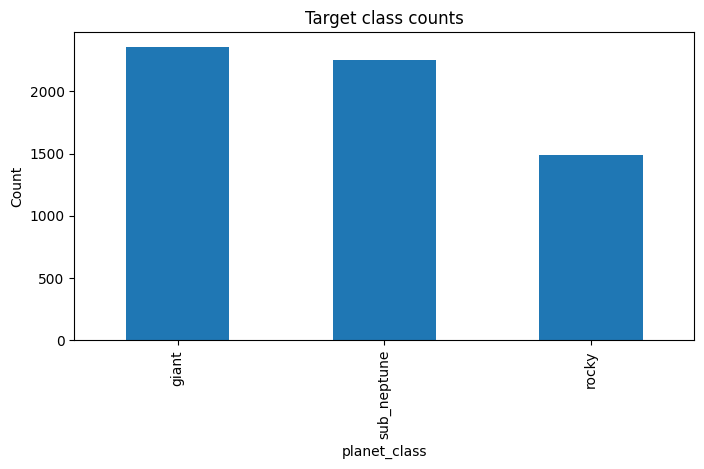

In [8]:
ax = df["planet_class"].value_counts().plot(kind="bar", figsize=(8,4))
ax.set_title("Target class counts")
ax.set_ylabel("Count")
plt.show()

### Student task
Inspect the class balance.  
Is this balanced enough for naive accuracy to be meaningful?

**Hint:** In imbalanced classification, balanced accuracy and macro-F1 are often more informative than plain accuracy.

In [11]:
balance = df["planet_class"].value_counts().to_frame("count").assign(fraction=lambda x: x["count"] / len(df)).reset_index().rename(columns={"index": "planet_class"})
print(balance)

  planet_class  count  fraction
0        giant   2357  0.386204
1  sub_neptune   2255  0.369490
2        rocky   1491  0.244306


The classes are reasonably balanced

## 4. Choose input features

We **exclude**
- `pl_rade` because it defines the target,
- names/identifiers because they do not represent physics,
- host names because they are identifiers rather than predictive variables.

We keep a compact physically interpretable set of orbital, planetary, and stellar quantities.

In [12]:
feature_cols = [
    "pl_orbper",   # orbital period [days]
    "pl_orbsmax",  # semi-major axis [AU]
    "pl_orbeccen", # eccentricity
    "pl_bmasse",   # planet mass or M*sin(i) [Earth masses]
    "pl_dens",     # density [g/cm^3]
    "pl_eqt",      # equilibrium temperature [K]
    "pl_insol",    # insolation flux [Earth flux]
    "st_teff",     # stellar effective temperature [K]
    "st_rad",      # stellar radius [Solar radii]
    "st_mass",     # stellar mass [Solar masses]
    "st_met",      # metallicity [dex]
    "st_logg",     # stellar surface gravity
    "sy_dist",     # distance [pc]
    "sy_vmag",     # V magnitude
    "sy_kmag",     # K magnitude
]

target_col = "planet_class"

data = df[feature_cols + [target_col]].copy()
data.head()

,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag,sy_kmag,planet_class
0,1.003934,0.01750,0.0,3.570,3.92,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470,13.663,rocky
1,8.172400,0.07790,0.0,11.000,1.65,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540,13.695,sub_neptune
2,6.283855,0.06865,0.0,0.437,4.69,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420,11.025,rocky
3,3.173917,0.04641,0.0,10.100,1.78,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310,12.574,sub_neptune
4,56.358501,0.26980,0.0,18.700,1.10,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249,13.999,giant


## 5. Optional astrophysical filtering

Archive tables may include heterogeneous measurement quality and strong incompleteness.

For a pedagogical first pass, we keep the dataset fairly broad.  
But for a stricter scientific analysis, students may wish to require:
- non-null mass,
- non-null equilibrium temperature,
- bounded eccentricity,
- removal of extreme outliers.

Below we do only minimal sanity filtering.

In [13]:
# Remove obviously problematic or non-physical values in a conservative way
data = data.copy()
data = data[(data["pl_orbper"].isna()) | (data["pl_orbper"] > 0)]
data = data[(data["pl_orbsmax"].isna()) | (data["pl_orbsmax"] > 0)]
data = data[(data["pl_bmasse"].isna()) | (data["pl_bmasse"] > 0)]
data = data[(data["st_mass"].isna()) | (data["st_mass"] > 0)]
data = data[(data["st_rad"].isna()) | (data["st_rad"] > 0)]
data = data[(data["sy_dist"].isna()) | (data["sy_dist"] > 0)]

print("Filtered shape:", data.shape)
data[target_col].value_counts()

Filtered shape: (6103, 16)


planet_class
giant          2357
sub_neptune    2255
rocky          1491
Name: count, dtype: int64

## 6. Quick exploratory plots

We will inspect a few astrophysically relevant relationships.

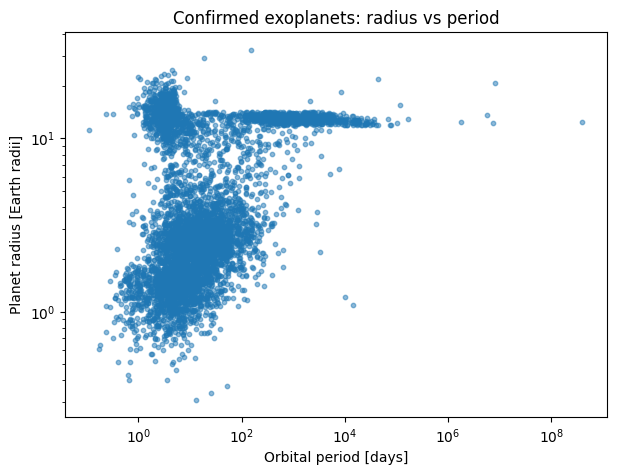

In [14]:
plot_df = df.copy()

plt.figure(figsize=(7,5))
mask = plot_df["pl_orbper"].notna() & plot_df["pl_rade"].notna()
plt.scatter(plot_df.loc[mask, "pl_orbper"], plot_df.loc[mask, "pl_rade"], s=10, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Orbital period [days]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("Confirmed exoplanets: radius vs period")
plt.show()

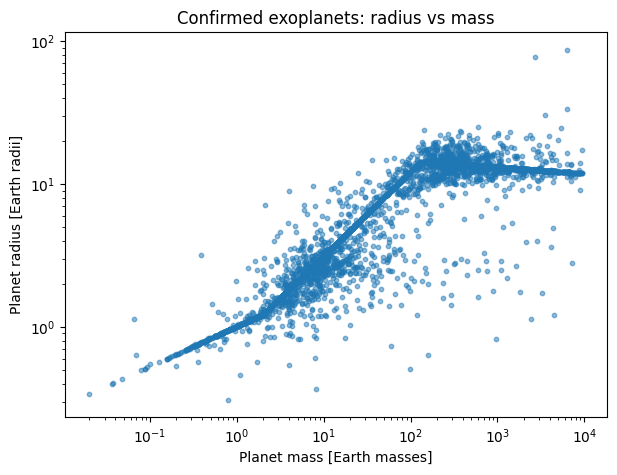

In [15]:
plt.figure(figsize=(7,5))
mask = plot_df["pl_bmasse"].notna() & plot_df["pl_rade"].notna()
plt.scatter(plot_df.loc[mask, "pl_bmasse"], plot_df.loc[mask, "pl_rade"], s=10, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Planet mass [Earth masses]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("Confirmed exoplanets: radius vs mass")
plt.show()

### Student task
From the two plots above, answer:
1. Which relation looks more directly predictive of radius class?
2. Which relation is likely to be affected more strongly by discovery bias?
3. Would you expect `pl_bmasse` to dominate feature importance? Why or why not?

1. **Planet mass** looks more directly predictive showing an clear trend in log space
2. **Orbital period vs planet radius** is more strongly affected by discovery bias. The main detection methods preferentially select certain kind of planets. We can see in the plot that certain regions are overrepressented while others are underrrepresented. On the other hand the planet mass vs planet radius relation reflects a physical structure (mass-density relationship), that doesn't depend on the planet's orbit.
3. Yes because of the clear relation we can observe with the radius, which we used to define the target class

## 7. Train-test split

We perform a stratified split so the class proportions are preserved.

In [16]:
X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (4577, 15)
Test shape: (1526, 15)

Training class distribution:
planet_class
giant          0.386279
sub_neptune    0.369456
rocky          0.244265
Name: proportion, dtype: float64

Test class distribution:
planet_class
giant          0.385976
sub_neptune    0.369594
rocky          0.244430
Name: proportion, dtype: float64


## 8. Build the preprocessing + model pipeline

Random Forest does **not** require feature scaling, but it does require a strategy for missing values.

We therefore use:
- median imputation for all numeric columns,
- RandomForestClassifier for the model.

We also use `class_weight="balanced_subsample"` to reduce the effect of class imbalance.

In [17]:
numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    min_samples_split=6,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

## 9. Cross-validation on the training set

We evaluate with:
- balanced accuracy,
- macro F1,
- weighted F1.

This is better than relying on one train/test split alone.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted"
    },
    n_jobs=-1,
    return_train_score=False
)

pd.DataFrame(cv_results)

,fit_time,score_time,test_balanced_accuracy,test_f1_macro,test_f1_weighted
0,1.442069,0.068378,0.964783,0.965355,0.965041
1,1.417746,0.081871,0.969958,0.972560,0.972698
2,1.474136,0.068969,0.978884,0.979364,0.978130
3,1.449444,0.073005,0.958792,0.960987,0.961787
4,1.440908,0.071721,0.964929,0.965636,0.965091


In [19]:
summary = pd.DataFrame({
    metric: [np.mean(values), np.std(values)]
    for metric, values in cv_results.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T

summary

,mean,std
test_balanced_accuracy,0.967469,0.006715
test_f1_macro,0.968781,0.006460
test_f1_weighted,0.968550,0.005983


### Student task
Interpret the difference between:
- macro F1
- weighted F1
- balanced accuracy

Which one is most appropriate if the rarest class is scientifically important?

## 10. Fit final model and evaluate on the test set

In [20]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred))

Balanced accuracy: 0.9684349999517389
Macro F1: 0.9698063751124314
Weighted F1: 0.9704772722856828

              precision    recall  f1-score   support

       giant       0.98      0.99      0.98       589
       rocky       0.98      0.95      0.97       373
 sub_neptune       0.96      0.96      0.96       564

    accuracy                           0.97      1526
   macro avg       0.97      0.97      0.97      1526
weighted avg       0.97      0.97      0.97      1526



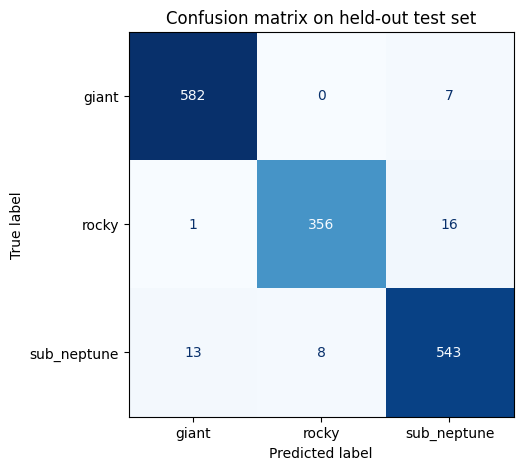

In [21]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix on held-out test set")
plt.show()

## 11. Permutation importance

Tree-based impurity importance can be biased, so we also compute **permutation importance** on the test set.

This is often more trustworthy for interpretation.

In [22]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
3,pl_bmasse,0.431988,0.011885
4,pl_dens,0.209463,0.010422
1,pl_orbsmax,0.002327,0.001400
13,sy_vmag,0.001871,0.000866
14,sy_kmag,0.001863,0.001227
11,st_logg,0.001335,0.000536
10,st_met,0.000829,0.000560
7,st_teff,0.000471,0.000402
9,st_mass,0.000399,0.000473
12,sy_dist,0.000113,0.000508


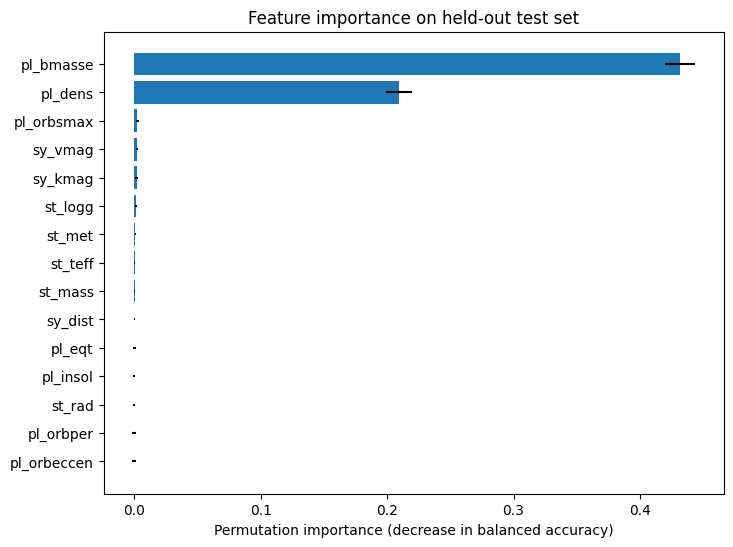

In [23]:
plt.figure(figsize=(8,6))
plt.barh(importance_df["feature"], importance_df["importance_mean"], xerr=importance_df["importance_std"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance (decrease in balanced accuracy)")
plt.title("Feature importance on held-out test set")
plt.show()

### Student task
Discuss the top-ranked features:

1. Are they physically plausible?
2. Could any of them be proxies for detection bias rather than intrinsic planet structure?
3. Would the ranking change if you removed `pl_bmasse` or `pl_dens`?

## 12. Optional extension: compare two feature sets

A useful scientific exercise is to compare:

### Model A
All selected features

### Model B
Only stellar + orbital features  
(excluding direct planet-structure features such as `pl_bmasse` and `pl_dens`)

This tests how much of the classification depends on direct structural information versus environment.

In [24]:
feature_cols_B = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen",
    "pl_eqt",
    "pl_insol",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
    "sy_dist",
    "sy_vmag",
    "sy_kmag",
]

X_B = data[feature_cols_B]
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), feature_cols_B)
    ]
)

model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        min_samples_split=6,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

cv_results_B = cross_validate(
    model_B,
    X_train_B,
    y_train_B,
    cv=cv,
    scoring={
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted"
    },
    n_jobs=-1
)

summary_B = pd.DataFrame({
    metric: [np.mean(values), np.std(values)]
    for metric, values in cv_results_B.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T

summary_B

,mean,std
test_balanced_accuracy,0.712238,0.010561
test_f1_macro,0.713254,0.010447
test_f1_weighted,0.726139,0.010781


### Compare the two models
If Model A substantially outperforms Model B, that likely means direct planet-structure features carry much of the predictive signal. That is not surprising, but it is scientifically useful to quantify.

This comparison also opens a very good classroom discussion:
> Is the model learning a physically deep relation, or is it largely exploiting nearby observables?

We can see that model A outperforms B

## 13. Optional extension: regression instead of classification

A strong extension for advanced students is to switch from classification to regression and predict:
- `pl_bmasse`, or
- `pl_eqt`, or
- `pl_dens`

using `RandomForestRegressor`.

Students can then compare:
- RMSE / MAE,
- residual plots,
- feature importance,
- regression versus classification framing.

## 14. Scientific caveats students must mention in their report

Any serious report should discuss the following:

### 1. Archive heterogeneity
The confirmed exoplanet sample is not a homogeneous survey product.

### 2. Selection effects
Transit, radial velocity, imaging, microlensing, and timing methods probe different regions of parameter space.

### 3. Missing-data mechanism
Missingness is not necessarily random.

### 4. Target construction
The class boundaries (`1.8` and `4.0` Earth radii) are pedagogical approximations.

### 5. Feature leakage risk
Always verify that target-defining quantities are not indirectly reintroduced.

### 6. Prediction is not causation
A strong classifier does not prove that the top feature is a causal driver.

## 15. Suggested student report questions

1. How many planets were retrieved from the archive at the time you ran the notebook?
2. What was the class distribution?
3. Which features had the highest permutation importance?
4. Which class was hardest to classify, and why?
5. How did the reduced-feature model compare to the full model?
6. Which astrophysical or observational biases may affect the conclusions?
7. What would you change to make the analysis more scientifically rigorous?

## 16. Challenge problems

### Challenge A
Replace the target with a binary label:
- `small_planet` if `pl_rade < 4`
- `giant_planet` otherwise

Compare performance with the 3-class problem.

### Challenge B
Restrict the dataset to only planets discovered by the transit method.  
Does performance improve or worsen?

### Challenge C
Train a model to predict `discoverymethod` from physical and stellar features.  
What does that teach you about selection effects?

### Challenge D
Use grouped cross-validation by `hostname` so planets in the same system do not leak between train and test.

### Challenge E
Compare Random Forest with:
- Logistic Regression
- XGBoost or HistGradientBoosting
- ExtraTreesClassifier